# AlphaGenome variant-effect predictions

For each variant, `predictions/{name}/bin_{b}.json` (b = 0..1023) holds one sliding-window run where the variant sits at output bin `b` (`var_bin == b`), with a full `(1024,)` `ve` / `ve_rc` array (predicted effect at every output-bin position).

Per variant, take only the value at the variant's own bin, `ve[var_bin]` (= the diagonal of the (windows, positions) matrix), for each window b = 0..1023. Line plot: x = bin b (window index), y = `ve[var_bin]` — one line per variant — shows how the predicted effect at the variant itself changes as the window slides (i.e. as the amount of random left-padding / real right-context changes). Plotted separately for `ve` and `ve_rc`, dark background.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np

plt.style.use("dark_background")

PRED_DIR = "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/8-aphagenome/pytorch/predictions"
N_BINS = 1024

In [2]:
variants = sorted(
    d for d in os.listdir(PRED_DIR) if os.path.isdir(os.path.join(PRED_DIR, d))
)
print(f"{len(variants)} variants: {variants}")

2 variants: ['C228T', 'C250T']


In [3]:
def load_variant_matrices(name: str) -> tuple[np.ndarray, np.ndarray]:
    """Return (ve, ve_rc), each shape (N_BINS windows, N_BINS positions).

    Row b = bin_{b}.json (window placing the variant at output bin b).
    Column i = predicted effect at output-bin position i within that window.
    """
    ve = np.empty((N_BINS, N_BINS), dtype=np.float32)
    ve_rc = np.empty((N_BINS, N_BINS), dtype=np.float32)
    for b in range(N_BINS):
        path = os.path.join(PRED_DIR, name, f"bin_{b}.json")
        with open(path) as f:
            d = json.load(f)
        ve[b] = d["ve"]
        ve_rc[b] = d["ve_rc"]
    return ve, ve_rc


ve_matrices = {}
ve_rc_matrices = {}
for name in variants:
    ve_m, ve_rc_m = load_variant_matrices(name)
    ve_matrices[name] = ve_m
    ve_rc_matrices[name] = ve_rc_m

{n: m.shape for n, m in ve_matrices.items()}

{'C228T': (1024, 1024), 'C250T': (1024, 1024)}

In [4]:
def variant_bin_diagonal(matrix: np.ndarray) -> np.ndarray:
    """Value at the variant's own bin (ve[var_bin]) for each window b.

    bin_{b}.json always places the variant at output bin b (var_bin == b),
    so this is just the diagonal of the (windows, positions) matrix.
    """
    return np.diagonal(matrix).copy()


ve_diag = {name: variant_bin_diagonal(m) for name, m in ve_matrices.items()}
ve_rc_diag = {name: variant_bin_diagonal(m) for name, m in ve_rc_matrices.items()}

In [5]:
def plot_line(diag: dict[str, np.ndarray], title: str, ylabel: str):
    fig, ax = plt.subplots(figsize=(10, 5), facecolor="black")
    x = np.arange(N_BINS)
    for name, y in diag.items():
        ax.plot(x, y, label=name, linewidth=1)
    ax.set_xlabel("bin b (window index = var_bin)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    return fig

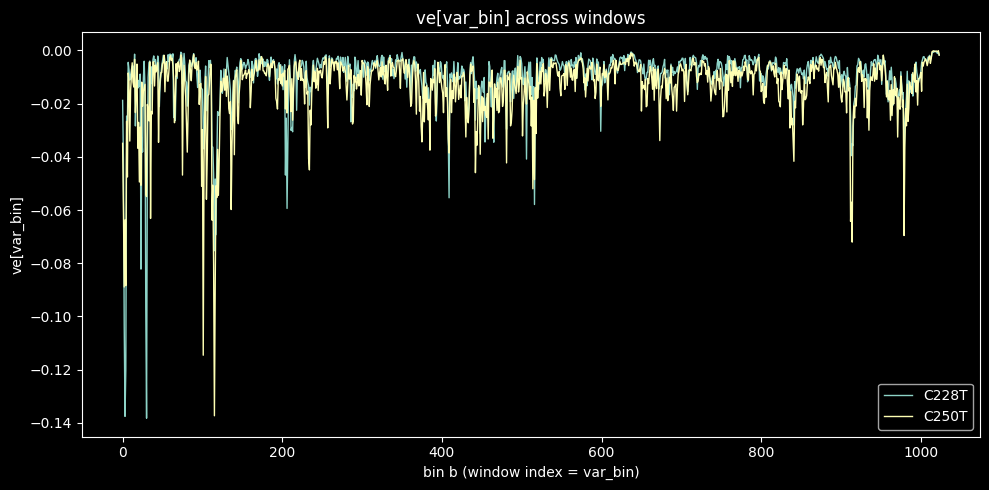

In [6]:
_ = plot_line(ve_diag, "ve[var_bin] across windows", "ve[var_bin]")

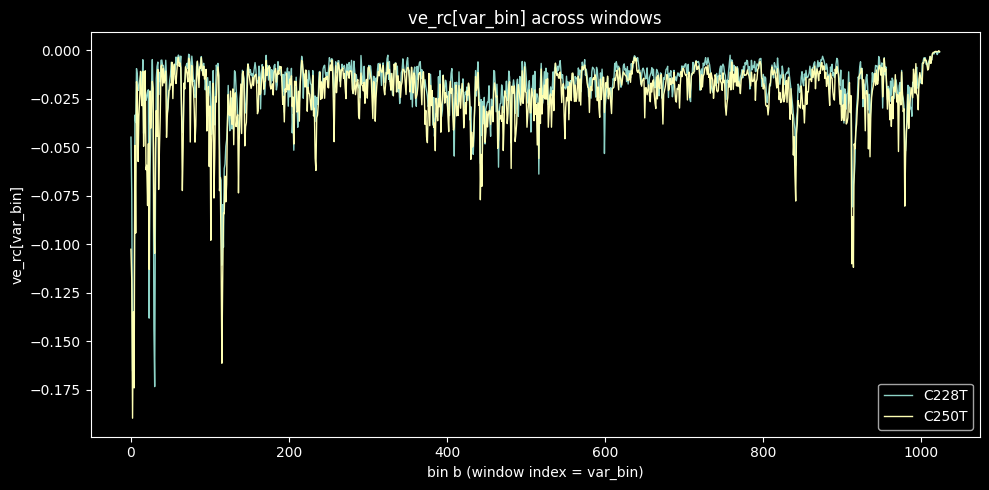

In [7]:
_ = plot_line(ve_rc_diag, "ve_rc[var_bin] across windows", "ve_rc[var_bin]")